**Steps**
1. Install all dependencies
2. Load Dataset
3. Data Exploration
4. Data Cleaning
5. Feature Scaling
6. Handle Imbalanced Data
7. Train ML Model
8. Evaluate Model
9. Fraud Prediction

Task 1: Installing all dependencies

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Handling imbalanced data
from imblearn.over_sampling import SMOTE 

Task 2: Load Dataset


In [2]:
data = pd.read_csv("C:/Users/nihar/Downloads/creditcard.csv")

Task 3: Data Exploration

In [3]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [5]:
data.shape

(284807, 31)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
data['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [8]:
# Statistical Summary
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Task 4: Data cleaning

In [9]:
# dealing with duplicated value rows

data.duplicated().sum()

data[data.duplicated()]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
282987,171288.0,1.912550,-0.455240,-1.750654,0.454324,2.089130,4.160019,-0.881302,1.081750,1.022928,...,-0.524067,-1.337510,0.473943,0.616683,-0.283548,-1.084843,0.073133,-0.036020,11.99,0
283483,171627.0,-1.464380,1.368119,0.815992,-0.601282,-0.689115,-0.487154,-0.303778,0.884953,0.054065,...,0.287217,0.947825,-0.218773,0.082926,0.044127,0.639270,0.213565,0.119251,6.82,0
283485,171627.0,-1.457978,1.378203,0.811515,-0.603760,-0.711883,-0.471672,-0.282535,0.880654,0.052808,...,0.284205,0.949659,-0.216949,0.083250,0.044944,0.639933,0.219432,0.116772,11.93,0
284191,172233.0,-2.667936,3.160505,-3.355984,1.007845,-0.377397,-0.109730,-0.667233,2.309700,-1.639306,...,0.391483,0.266536,-0.079853,-0.096395,0.086719,-0.451128,-1.183743,-0.222200,55.66,0


In [10]:
# deleting all duplicated rows

data.drop_duplicates(inplace=True)
data.duplicated().sum()

0

In [11]:
data['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [12]:
data.isnull().sum()

# dropping all missing values rows

data.dropna(inplace=True)

data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [13]:
data.shape

(283726, 31)

Task 5: Data Analysis

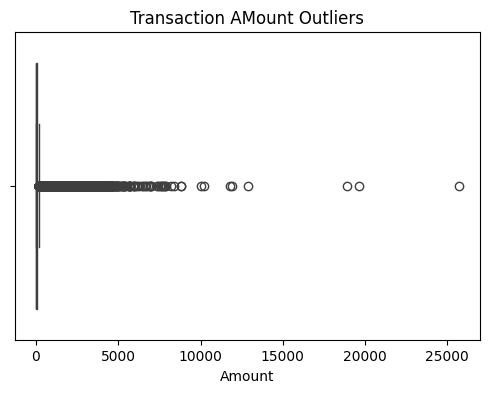

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x=data['Amount'])
plt.title("Transaction AMount Outliers")
plt.show()

**Bivariate Analysis**

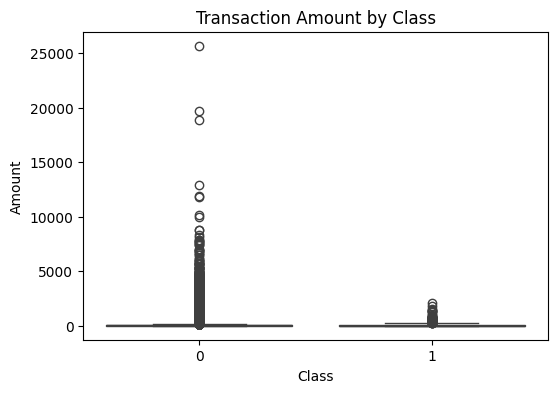

In [15]:
# Do fraud transactions have unusual amounts?

plt.figure(figsize=(6,4))
sns.boxplot(x='Class', y='Amount', data=data)
plt.title("Transaction Amount by Class")
plt.show()

**Univariate Analysis**

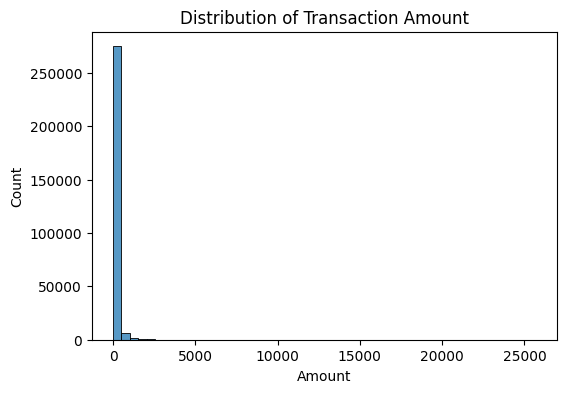

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(data['Amount'], bins=50)
plt.title("Distribution of Transaction Amount")
plt.show()


#Most credit card transactions involve small amounts, while a small number of transactions have very high values.

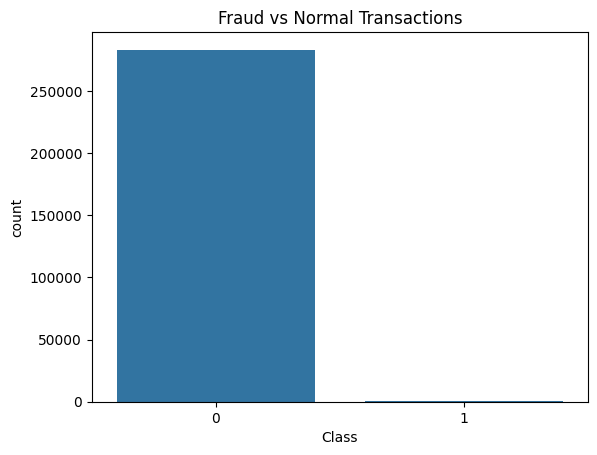

In [17]:
# This plot will clearly show the extreme imbalance.  

sns.countplot(x='Class', data=data)
plt.title("Fraud vs Normal Transactions")
plt.show()

**Multivariate**

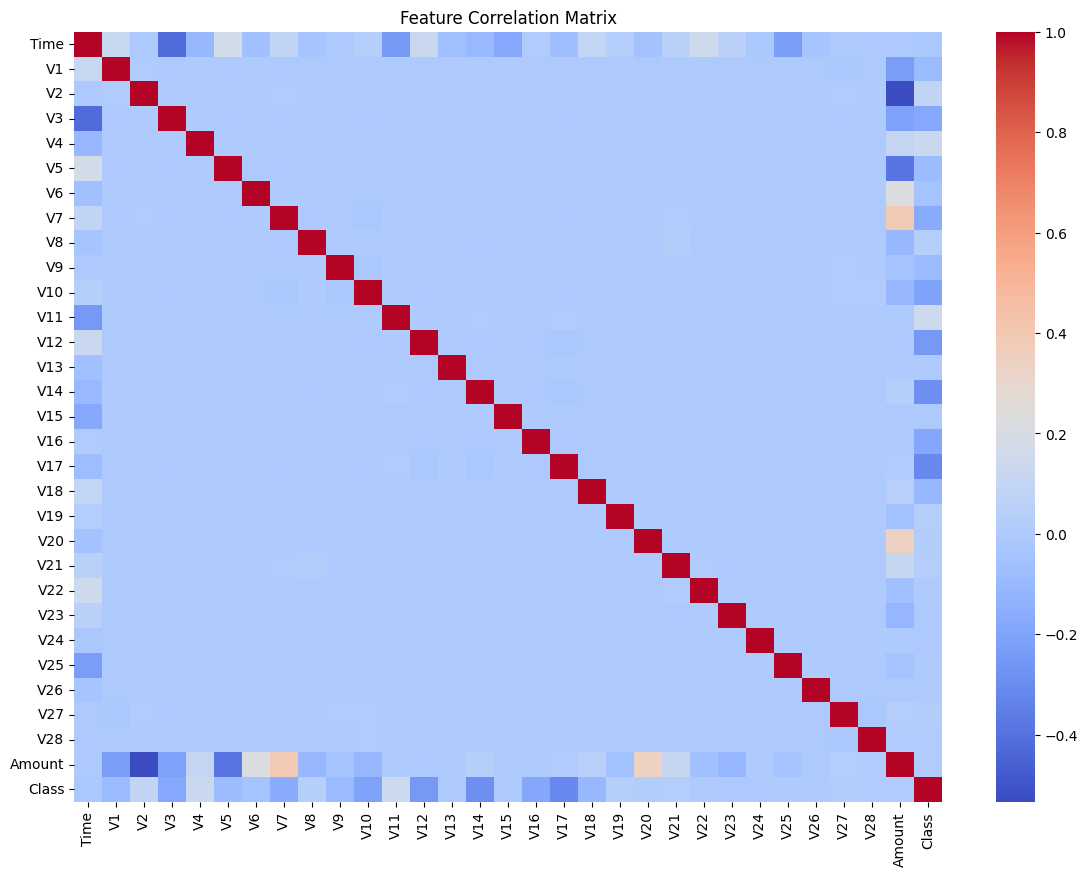

In [18]:
# Correlation heat map 
# Purpose : Shows relationships between features. Helps detect highly correlated variables.
corr = data.corr(numeric_only=True)
plt.figure(figsize=(14,10))
sns.heatmap(data.corr(),cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

**Feature comparison**

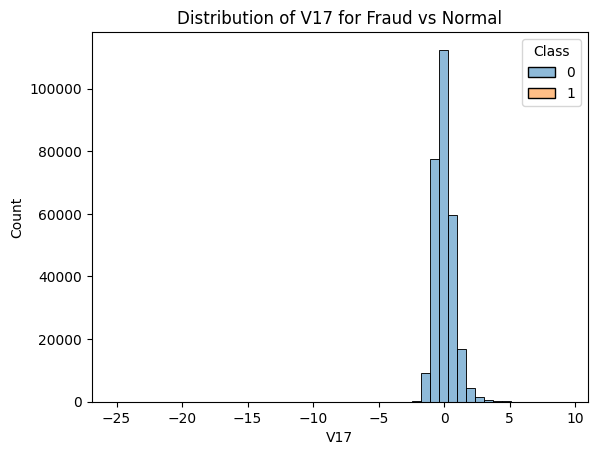

In [19]:
sns.histplot(data=data,x="V17",hue="Class",bins=50)
plt.title("Distribution of V17 for Fraud vs Normal")
plt.show()

Key Observations:

1. Dataset is extremely imbalanced (Fraud ≈ 0.17%).
2. Most transaction amounts are small.
3. Fraud transactions tend to have smaller values than normal ones.
4. PCA features show low correlation as expected.

Task 6: Data Preprocessing

Feature Scaling

In [20]:
# All PCA features are already normalized, but Amount is not.

scaler = StandardScaler()
data['scaled_amount'] = scaler.fit_transform(data[['Amount']])

data = data.drop(['Amount'],axis=1)

In [21]:
scaler = StandardScaler()

data['scaled_time'] = scaler.fit_transform(data[['Time']])

data = data.drop(['Time'], axis=1)

In [22]:
print(data.columns)

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class',
       'scaled_amount', 'scaled_time'],
      dtype='object')


In [23]:
x = data.drop(['Class'],axis = 1)
y = data['Class']

Train Test Split

In [24]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

Handle Imbalanced Data

In [25]:
smote = SMOTE(random_state=42)
x_train_resampled,y_train_resampled = smote.fit_resample(x_train,y_train)

Training ML Model.
1. Logistic Regression

In [26]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train_resampled,y_train_resampled)


# Evaluate model

y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:,1]

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print("ROC-AUC:",roc_auc_score(y_test,y_prob))

[[55170  1481]
 [   12    83]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746

ROC-AUC: 0.9620358817468729


In [27]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train_resampled,y_train_resampled)

#Evaluate model
y_pred = dt.predict(x_test)
y_prob = dt.predict_proba(x_test)[:,1]

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print("ROC-AUC:",roc_auc_score(y_test,y_prob))

[[56552    99]
 [   28    67]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.40      0.71      0.51        95

    accuracy                           1.00     56746
   macro avg       0.70      0.85      0.76     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.8517578079636258


In [28]:
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    n_jobs=-1,   # use all CPU cores
    random_state=42
)
rf.fit(x_train_resampled,y_train_resampled)

# evaluate model
y_pred = rf.predict(x_test)
y_prob = rf.predict_proba(x_test)[:,1]

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print("ROC-AUC:",roc_auc_score(y_test,y_prob))

[[56587    64]
 [   20    75]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.54      0.79      0.64        95

    accuracy                           1.00     56746
   macro avg       0.77      0.89      0.82     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9796257603108227


Model Comparison - ROC Curve

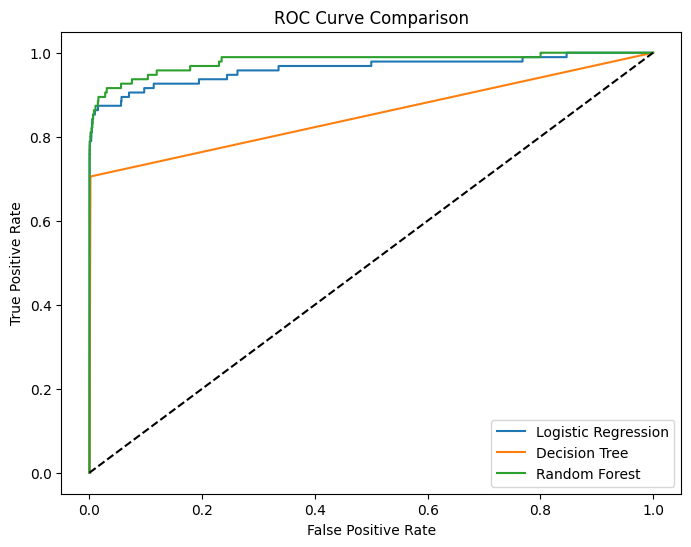

In [29]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Logistic Regression
y_prob_lr = model.predict_proba(x_test)[:,1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

# Decision Tree
y_prob_dt = dt.predict_proba(x_test)[:,1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

# Random Forest
y_prob_rf = rf.predict_proba(x_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_dt, tpr_dt, label="Decision Tree")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    return {
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }


In [31]:
results = []

results.append(evaluate_model("Logistic Regression", model, x_test, y_test))
results.append(evaluate_model("Decision Tree", dt, x_test, y_test))
results.append(evaluate_model("Random Forest", rf, x_test, y_test))

In [32]:
comparison = pd.DataFrame(results)
print(comparison)

                 Model  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression   0.053069  0.873684  0.100060  0.962036
1        Decision Tree   0.403614  0.705263  0.513410  0.851758
2        Random Forest   0.539568  0.789474  0.641026  0.979626


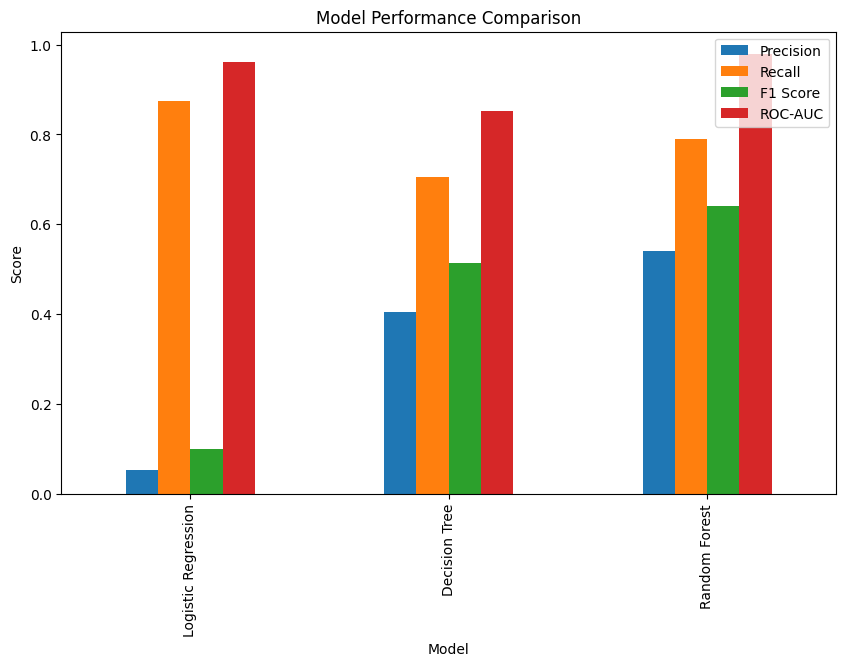

In [33]:
comparison.set_index("Model").plot(kind="bar", figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()

Saving Best Model

In [34]:
import joblib
joblib.dump(rf, "model.pkl")

['model.pkl']

**Model Performance Insights**
1. Logistic Regression:
   - Achieved the highest recall (0.87), meaning it is very effective at detecting fraud cases.
   - However, it has extremely low precision (0.05), indicating a large number of false positives.
   - This makes it suitable when minimizing missed fraud is critical, but inefficient in real-world systems due to excessive alerts.

2. Decision Tree:
   - Provides a balance between precision (0.40) and recall (0.71).
   - Performs better than Logistic Regression in reducing false positives.
   - However, it misses more fraud cases compared to Logistic Regression.

3. Random Forest:
   - Achieves the best overall performance with high precision (0.54), good recall (0.79), and the highest ROC-AUC (~0.98).
   - This indicates strong ability to distinguish between fraud and normal transactions.
   - Provides the best trade-off between detecting fraud and minimizing false alarms.

**Key Observation**

In fraud detection problems, recall is more important than accuracy,
because missing fraudulent transactions can lead to significant financial loss.

**Final Conclusion**

Based on the comparison, Random Forest is the most suitable model for this problem,
as it provides a strong balance between precision and recall, along with the highest ROC-AUC score.

Although Logistic Regression detects more fraud cases, its very low precision makes it less practical.
Decision Tree performs moderately but is outperformed by Random Forest.

In [35]:
import os
print(os.getcwd())

d:\Credit Card Fraud Detection


In [36]:
# import pickle
# import os

# path = os.path.join(os.getcwd(), "model.pkl")
# pickle.dump(rf, open(path, "wb"))

# print("Saved at:", path)